# Data Preprocessing

## Konfigurasi Global

In [ ]:
IS_USING_FFT_DOMAIN = False


ROOT_PROJECT_DATASET = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing"
BEARING_VARIATION_FOLDER = ("bearing_1", )

MAIN_BEARING = BEARING_VARIATION_FOLDER[0] # Pilih bearing utama untuk analisis
SAMPLING_RATE = 2560

In [ ]:
'''
HI : BLACK - Full line
TP : RED - Full line
X : BLUE - Full Line 
Y : ORANGE - Full line 
Z : GREEN - Full line
'''

PLOT_STYLES = {
    "HI": {"color": "black", "linestyle": "-"},
    "HI_PRED": {"color": "gold", "linestyle": "--"},
    "TP": {"color": "red", "linestyle": "-"},
    "TP_PRED": {"color": "red", "linestyle": "--"},
    "X": {"color": "blue", "linestyle": "-"},
    "Y": {"color": "orange", "linestyle": "-"},
    "Z": {"color": "green", "linestyle": "-"},
}

## Import

In [3]:
import os
import glob
import re

import numpy as np
from numpy.fft import rfft, rfftfreq

import pandas as pd

import dask.dataframe as dd
import dask.array as da
from dask.diagnostics.progress import ProgressBar

import torch
import torch.optim as optim
import torch.nn as nn

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

import plotly.graph_objs as go
import plotly.offline as pyo

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns

from tqdm import tqdm  # Import tqdm for progress bar

import gc

## Helper Functions

In [4]:
def temp_output_bearing_root(bearing_name: str) -> str:
    return f"{ROOT_PROJECT_DATASET}/{bearing_name}"

def bearing_file_full_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_full.parquet"

def bearing_file_raw_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_raw.parquet"

def bearing_file_fft_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_fft.parquet"


def calculate_series_health_index(t: float, Tcp: float, Tf: float) -> float:
    """Calculate the health index based on time, Tcp, and Tf.
    Args:
        t (float): current time
        Tcp (float): turning point time
        Tf (float): max time

    Returns:
        float: health index value between 0 (Broken) and 1 (Good)
    """
    return 1 - ( max((t - Tcp), 0) / (Tf - Tcp) )

def calculate_health_index_to_rul(health_index, Tf: float) -> float:
    """
    Convert health index (HI) to RUL.
    HI: 1.0 = new, 0.0 = failed
    max_rul: maximum RUL (e.g., total life in seconds or cycles)
    """
    return np.clip(health_index, 0, 1) * Tf

## A. Label Health Index Status

### 1. Baca data parquet

In [56]:
if not IS_USING_FFT_DOMAIN:
    # Raw Time Domain
    _temp_dataset = dd.read_parquet(bearing_file_full_parquet(MAIN_BEARING))
    group_raw_by_seconds = _temp_dataset.assign(time_group=_temp_dataset['time'] // 1).astype({'time_group': 'int32'})
    _dataset = group_raw_by_seconds.groupby('time_group').agg({
        'time': 'first',   # or 'min', 'max', or 'mean' as appropriate
        'X': 'mean',
        'Y': 'mean',
        'Z': 'mean'
    }).reset_index(drop=True)[['time', 'X', 'Y', 'Z']].sort_values(by='time')
    # Save to parquet
    with ProgressBar():
        _dataset.to_parquet(
            bearing_file_raw_parquet(MAIN_BEARING),
            engine="pyarrow",
            compression="snappy"
        )
    
    _DF = dd.read_parquet(bearing_file_raw_parquet(MAIN_BEARING))

else:
    # FFT Domain
    _DF = dd.read_parquet(bearing_file_fft_parquet(MAIN_BEARING))

[########################################] | 100% Completed | 206.02 s
[########################################] | 100% Completed | 206.02 s
[########################################] | 100% Completed | 230.18 s
[########################################] | 100% Completed | 230.18 s


### 2. Tentukan Bearing Lifespan dan Turning Point

In [ ]:
BEARING_LIFESPAN_TIME = _DF['time'].max().compute()
TURNING_POINT_TIME = 290000

### 3. Labelling Health Index

In [58]:
DF = _DF.copy().assign(
    health_index=_DF['time'].map(lambda t: calculate_series_health_index(t, TURNING_POINT_TIME, BEARING_LIFESPAN_TIME), meta=('health_index', 'float64'))
)

DF.tail()

,time,X,Y,Z,health_index
26,392272.0,0.007574,0.011491,0.012902,0.000015
2848,392273.0,0.015526,-0.012256,0.037379,0.000011
2845,392274.0,-0.013945,0.009847,0.029572,0.000008
22,392275.0,0.014194,-0.012327,-0.028243,0.000004
26,392276.0,-0.031804,-0.025228,-0.043106,0.000000


In [60]:
DF.head()

,time,X,Y,Z,health_index
2874,0.0,0.016087,-0.010778,-0.038212,1.0
2932,1.0,-0.047576,0.003521,-0.029556,1.0
2940,2.0,0.026193,0.001570,-0.010268,1.0
3004,3.0,0.010285,-0.010011,0.037799,1.0
2883,4.0,-0.004602,0.007767,0.052897,1.0


In [61]:
series_health_index = DF['health_index'].compute()
series_time = DF['time'].compute().reset_index(drop=True)

## [B. FFT FEATURE SELECTION]
Hanya berjalan jika variable IS_USING_FFT_DOMAIN bernilai True

### 1. [Explorasi Data Satu Frekuensi]

Konfigurasi Lokal

In [ ]:
SELECTED_FREQUENCY = 247 # 0 - 1280 Hz

# Memory optimization To visualization purpose only (not for training)
_STEP = 100 
_SMOOTHING_WINDOW = 50

Visualisasi

In [63]:
if not IS_USING_FFT_DOMAIN:
    print(f"Skipping")
else:
    # Normal
    vis_data_fft_n_Hz_X = DF[f"FFT_{SELECTED_FREQUENCY}Hz_X"][::_STEP].compute().reset_index(drop=True)
    vis_data_fft_n_Hz_Y = DF[f"FFT_{SELECTED_FREQUENCY}Hz_Y"][::_STEP].compute().reset_index(drop=True)
    vis_data_fft_n_Hz_Z = DF[f"FFT_{SELECTED_FREQUENCY}Hz_Z"][::_STEP].compute().reset_index(drop=True)

    fig, ax1 = plt.subplots(figsize=(16, 9))

    ax1.plot(vis_data_fft_n_Hz_X, label=f"FFT_{SELECTED_FREQUENCY}Hz_X", **PLOT_STYLES["X"])
    ax1.plot(vis_data_fft_n_Hz_Y, label=f"FFT_{SELECTED_FREQUENCY}Hz_Y", **PLOT_STYLES["Y"])
    ax1.plot(vis_data_fft_n_Hz_Z, label=f"FFT_{SELECTED_FREQUENCY}Hz_Z", **PLOT_STYLES["Z"])
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Amplitude")
    ax1.set_title(f"FFT_{SELECTED_FREQUENCY}Hz")
    ax1.legend(loc="upper left")
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(series_time, series_health_index, label="Health Index (HI)", **PLOT_STYLES["HI"])
    ax2.set_ylabel("Health Index (HI)", color=PLOT_STYLES["HI"]["color"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLES["HI"]["color"])
    ax1.axvline(TURNING_POINT_TIME, linewidth=2, label='Turning Point', **PLOT_STYLES["TP"])
   
    plt.show()

    # Smoothed
    vis_data_fft_s_Hz_X = vis_data_fft_n_Hz_X.rolling(window=_SMOOTHING_WINDOW, min_periods=1).mean()
    vis_data_fft_s_Hz_Y = vis_data_fft_n_Hz_Y.rolling(window=_SMOOTHING_WINDOW, min_periods=1).mean()
    vis_data_fft_s_Hz_Z = vis_data_fft_n_Hz_Z.rolling(window=_SMOOTHING_WINDOW, min_periods=1).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(vis_data_fft_s_Hz_X, label=f"Smoothed FFT_{SELECTED_FREQUENCY}Hz_X", **PLOT_STYLES["X"])
    plt.plot(vis_data_fft_s_Hz_Y, label=f"Smoothed FFT_{SELECTED_FREQUENCY}Hz_Y", **PLOT_STYLES["Y"])
    plt.plot(vis_data_fft_s_Hz_Z, label=f"Smoothed FFT_{SELECTED_FREQUENCY}Hz_Z", **PLOT_STYLES["Z"])
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Amplitude")
    ax1.set_title(f"FFT_{SELECTED_FREQUENCY}Hz")
    ax1.legend(loc="upper left")
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(series_time, series_health_index, label="Health Index (HI)", **PLOT_STYLES["HI"])
    ax2.set_ylabel("Health Index (HI)", color=PLOT_STYLES["HI"]["color"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLES["HI"]["color"])
    ax1.axvline(TURNING_POINT_TIME, linewidth=2, label='Turning Point', **PLOT_STYLES["TP"])
   
    plt.show()

    del vis_data_fft_n_Hz_X, vis_data_fft_n_Hz_Y, vis_data_fft_n_Hz_Z
    del vis_data_fft_s_Hz_X, vis_data_fft_s_Hz_Y, vis_data_fft_s_Hz_Z

Skipping


In [64]:
del _STEP, _SMOOTHING_WINDOW

### 2. [Explorasi Data Gabungan Frekuensi]

Konfigurasi Lokal

In [ ]:
# 0 - 1280 Hz
FREQUENCY_MIN, FREQUENCY_MAX = 220, 260

# Memory optimization To visualization purpose only (not for training)
_SMOOTHING_WINDOW = 3600 * 4

Visualisasi

In [66]:
if not IS_USING_FFT_DOMAIN:
    print(f"Skipping")
else:
    frequency_range = range(FREQUENCY_MIN, FREQUENCY_MAX + 1)
    vis_data_mean_fft_X = DF[[f"FFT_{freq}Hz_X" for freq in frequency_range]].mean(axis=1).compute().reset_index(drop=True)
    vis_data_mean_fft_Y = DF[[f"FFT_{freq}Hz_Y" for freq in frequency_range]].mean(axis=1).compute().reset_index(drop=True)
    vis_data_mean_fft_Z = DF[[f"FFT_{freq}Hz_Z" for freq in frequency_range]].mean(axis=1).compute().reset_index(drop=True)

    fig, ax1 = plt.subplots(figsize=(16, 9))

    # Amplitudo
    ax1.plot(series_time, vis_data_mean_fft_X, label=f"Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - X", **PLOT_STYLES["X"])
    ax1.plot(series_time, vis_data_mean_fft_Y, label=f"Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - Y", **PLOT_STYLES["Y"])
    ax1.plot(series_time, vis_data_mean_fft_Z, label=f"Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - Z", **PLOT_STYLES["Z"])
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Mean Amplitude")
    ax1.set_title(f"Mean Amplitude and Health Index for {FREQUENCY_MIN}-{FREQUENCY_MAX} Hz Frequency Range")
    ax1.legend(loc="upper left")
    ax1.tick_params(axis='x', rotation=45)

    # Health Index
    ax2 = ax1.twinx()
    ax2.plot(series_time, series_health_index, label="Health Index (HI)", **PLOT_STYLES["HI"])
    ax2.set_ylabel("Health Index (HI)", color=PLOT_STYLES["HI"]["color"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLES["HI"]["color"])
    ax1.axvline(TURNING_POINT_TIME, linewidth=2, label='Turning Point', **PLOT_STYLES["TP"])

    plt.show()

    # Smoothed Amplitudo
    vis_data_mean_fft_s_X = vis_data_mean_fft_X.rolling(window=_SMOOTHING_WINDOW, min_periods=1).mean()
    vis_data_mean_fft_s_Y = vis_data_mean_fft_Y.rolling(window=_SMOOTHING_WINDOW, min_periods=1).mean()
    vis_data_mean_fft_s_Z = vis_data_mean_fft_Z.rolling(window=_SMOOTHING_WINDOW, min_periods=1).mean()

    fig, ax1 = plt.subplots(figsize=(16, 9))

    # Smoothed Amplitudo
    ax1.plot(series_time, vis_data_mean_fft_s_X, label=f"Smoothed Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - X", **PLOT_STYLES["X"])
    ax1.plot(series_time, vis_data_mean_fft_s_Y, label=f"Smoothed Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - Y", **PLOT_STYLES["Y"])
    ax1.plot(series_time, vis_data_mean_fft_s_Z, label=f"Smoothed Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - Z", **PLOT_STYLES["Z"])
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Mean Amplitude")
    ax1.set_title(f"Smoothed Mean Amplitude and Health Index for {FREQUENCY_MIN}-{FREQUENCY_MAX} Hz Frequency Range")
    ax1.legend(loc="upper left")
    ax1.tick_params(axis='x', rotation=45)

    # Health Index
    ax2 = ax1.twinx()
    ax2.plot(series_time, series_health_index, label="Health Index (HI)", **PLOT_STYLES["HI"])
    ax2.set_ylabel("Health Index (HI)", color=PLOT_STYLES["HI"]["color"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLES["HI"]["color"])
    ax1.axvline(TURNING_POINT_TIME, linewidth=2, label='Turning Point', **PLOT_STYLES["TP"])

    plt.show()


Skipping


visualisasi interaktif

In [67]:
if not IS_USING_FFT_DOMAIN:
    print(f"Skipping")
else:
    fig = go.Figure()

    # Add smoothed mean amplitude traces (primary y-axis)
    fig.add_trace(go.Scatter(
        x=series_time, y=vis_data_mean_fft_s_X, mode='lines', name=f"Smoothed Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - X",
        yaxis='y1'
    ))
    fig.add_trace(go.Scatter(
        x=series_time, y=vis_data_mean_fft_s_Y, mode='lines', name=f"Smoothed Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - Y",
        yaxis='y1'
    ))
    fig.add_trace(go.Scatter(
        x=series_time, y=vis_data_mean_fft_s_Z, mode='lines', name=f"Smoothed Mean Amplitude ({FREQUENCY_MIN}-{FREQUENCY_MAX} Hz) - Z",
        yaxis='y1'
    ))

    # Add Health Index trace (secondary y-axis)
    fig.add_trace(go.Scatter(
        x=series_time, y=series_health_index, mode='lines', name="Health Index (HI)",
        yaxis='y2', line=dict(color='black', dash='dash')
    ))

    # Add vertical line for the turning point
    fig.add_vline(
        x=TURNING_POINT_TIME,
        line=dict(color='orange', width=2, dash='dot'),
        annotation_text="Turning Point",
        annotation_position="top right"
    )

    # Update layout for dual y-axes
    fig.update_layout(
        title=f"Smoothed Mean Amplitude and Health Index for {FREQUENCY_MIN}-{FREQUENCY_MAX} Hz Frequency Range",
        xaxis=dict(title="Time"),
        yaxis=dict(
            title="Mean Amplitude",
            side='left'
        ),
        yaxis2=dict(
            title="Health Index (HI)",
            overlaying='y',
            side='right',
            showgrid=False
        ),
        legend=dict(
            x=0.99, y=-0.2,           
            xanchor="right", yanchor="top",
            bordercolor="Black",
            borderwidth=1,
            bgcolor="rgba(255,255,255,0.7)",  # Semi-transparent background
            font=dict(size=12)
        ),
        width=1000,
        height=600
    )

    fig.show()

Skipping


In [68]:
del _SMOOTHING_WINDOW

## C. Data Smoothing

Konfigurasi

In [ ]:
# Data Smoothing Configurations
SMOOTHING_WINDOW = 3600 * 4
DOWN_SAMPLING_FACTOR = 10 * 60 # in seconds
TESTING_INITIAL_POINT = 900

# Feature Selection Configurations For FFT Domain
# 0 - 1280 Hz
FREQUENCY_MIN, FREQUENCY_MAX = 220, 260

Helper Function

In [70]:
def export_dataset_root(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/datasets"

def export_dataset_name_for_fft_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/fft"

def export_dataset_name_for_raw_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/raw"

def plot_dataset_with_health_index(
    series_time,
    vis_data_X,
    vis_data_Y,
    vis_data_Z,
    label_X,
    label_Y,
    label_Z,
    title,
    health_index,
    turning_point_time,
):
    plt.figure(figsize=(12, 6))
    fig, ax1 = plt.subplots(figsize=(16, 9))

    # Plot FFT amplitudes on the primary y-axis
    ax1.plot(series_time, vis_data_X, label=label_X)
    ax1.plot(series_time, vis_data_Y, label=label_Y)
    ax1.plot(series_time, vis_data_Z, label=label_Z)
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Amplitude")
    ax1.tick_params(axis='x', rotation=45)

    # Add vertical line for the turning point
    ax1.axvline(turning_point_time, linewidth=2, label='Turning Point', **PLOT_STYLES["TP"])

    # Create a secondary y-axis for Health Index
    ax2 = ax1.twinx()
    ax2.plot(series_time, health_index, label='Health Index (HI)', **PLOT_STYLES["HI"])
    ax2.set_ylabel("Health Index (HI)", color=PLOT_STYLES["HI"]["color"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLES["HI"]["color"])

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.title(title)
    plt.grid()
    plt.tight_layout()
    plt.show()

### 1. Smoothing

In [71]:
if not IS_USING_FFT_DOMAIN:
    _data_X = DF['X'].compute()
    _data_Y = DF['Y'].compute()
    _data_Z = DF['Z'].compute()
else:
    # Feature Selection
    frequency_range = range(FREQUENCY_MIN, FREQUENCY_MAX + 1)
    _data_X = DF[[f"FFT_{freq}Hz_X" for freq in frequency_range]].mean(axis=1).compute().reset_index(drop=True)
    _data_Y = DF[[f"FFT_{freq}Hz_Y" for freq in frequency_range]].mean(axis=1).compute().reset_index(drop=True)
    _data_Z = DF[[f"FFT_{freq}Hz_Z" for freq in frequency_range]].mean(axis=1).compute().reset_index(drop=True)

# Data Smoothing
if SMOOTHING_WINDOW > 1:
    data_smooth_X = _data_X.rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()
    data_smooth_Y = _data_Y.rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()
    data_smooth_Z = _data_Z.rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()
else:
    data_smooth_X = _data_X
    data_smooth_Y = _data_Y
    data_smooth_Z = _data_Z

if not IS_USING_FFT_DOMAIN:
    DATASET = pd.DataFrame({
        "time" : series_time.reset_index(drop=True),
        "health_index" : series_health_index.reset_index(drop=True),
        "X": data_smooth_X.reset_index(drop=True),
        "Y": data_smooth_Y.reset_index(drop=True),
        "Z": data_smooth_Z.reset_index(drop=True),
    })
else:
    DATASET = pd.DataFrame({
        "time" : series_time.reset_index(drop=True),
        "health_index" : series_health_index.reset_index(drop=True),
        "FFT_X": data_smooth_X.reset_index(drop=True),
        "FFT_Y": data_smooth_Y.reset_index(drop=True),
        "FFT_Z": data_smooth_Z.reset_index(drop=True),
    })
    

## D. Data Cleaning

### 1. Cleaning

In [72]:
# Data Cleaning -- Remove rows with NaN values
DATASET = DATASET.dropna().reset_index(drop=True)

## E. Down Sampling

### 1. Down Sampling

In [73]:
# Training Dataset Export

## Down Sampling / Compress
DATASET_TRAINING = DATASET.iloc[::DOWN_SAMPLING_FACTOR].reset_index(drop=True)


# Testing Dataset Export

## Down Sampling / Compress
FFT_DATASET_TESTING = DATASET.iloc[TESTING_INITIAL_POINT::DOWN_SAMPLING_FACTOR].reset_index(drop=True)


### 2. Export

<Figure size 1200x600 with 0 Axes>

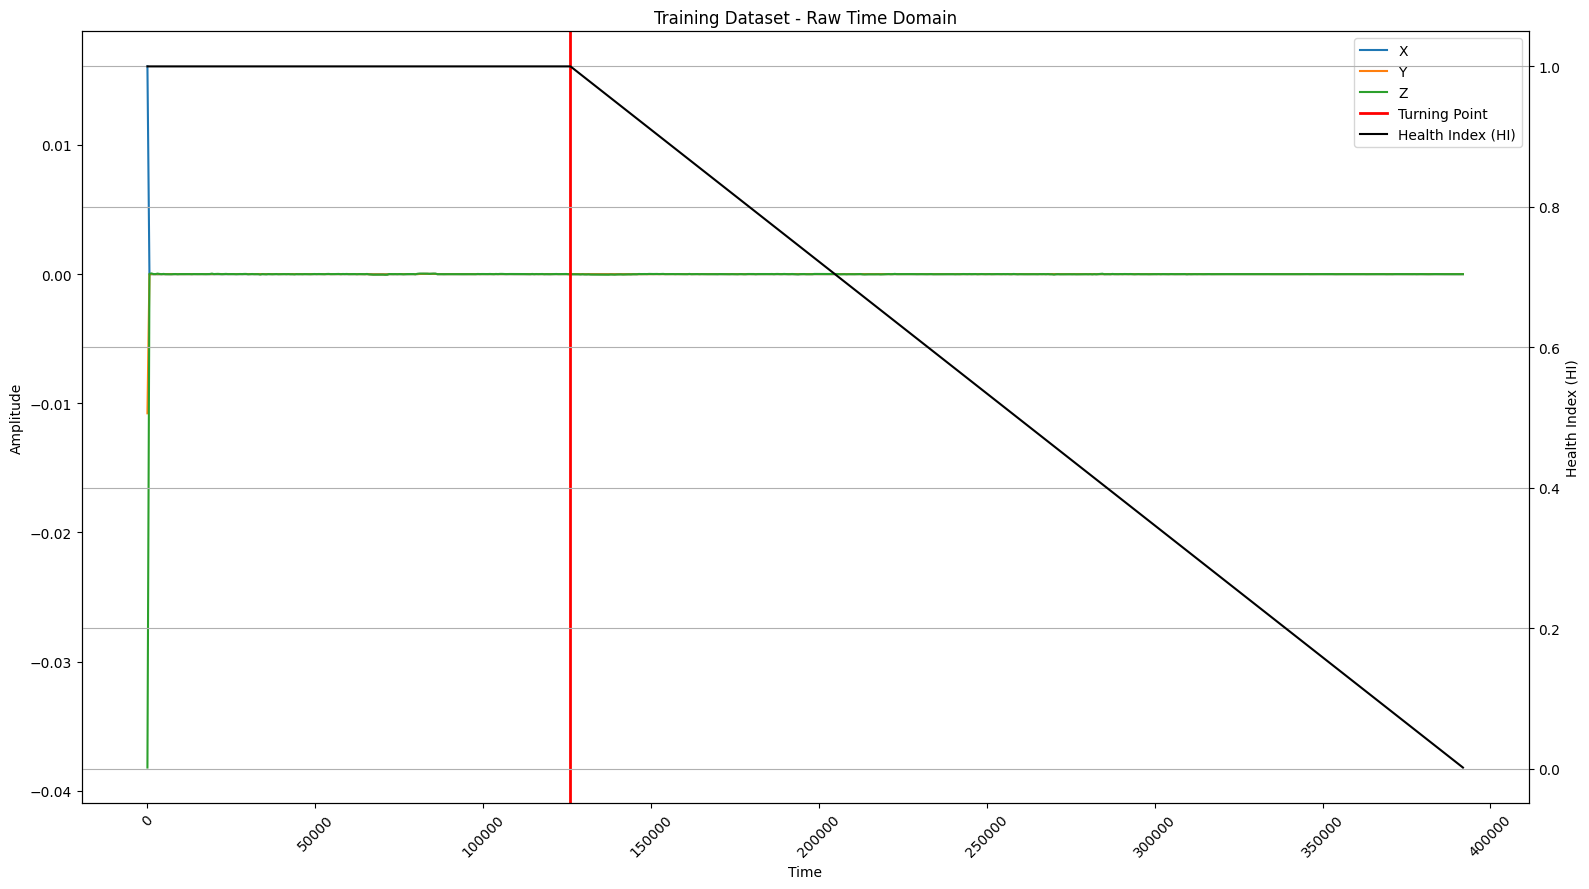

<Figure size 1200x600 with 0 Axes>

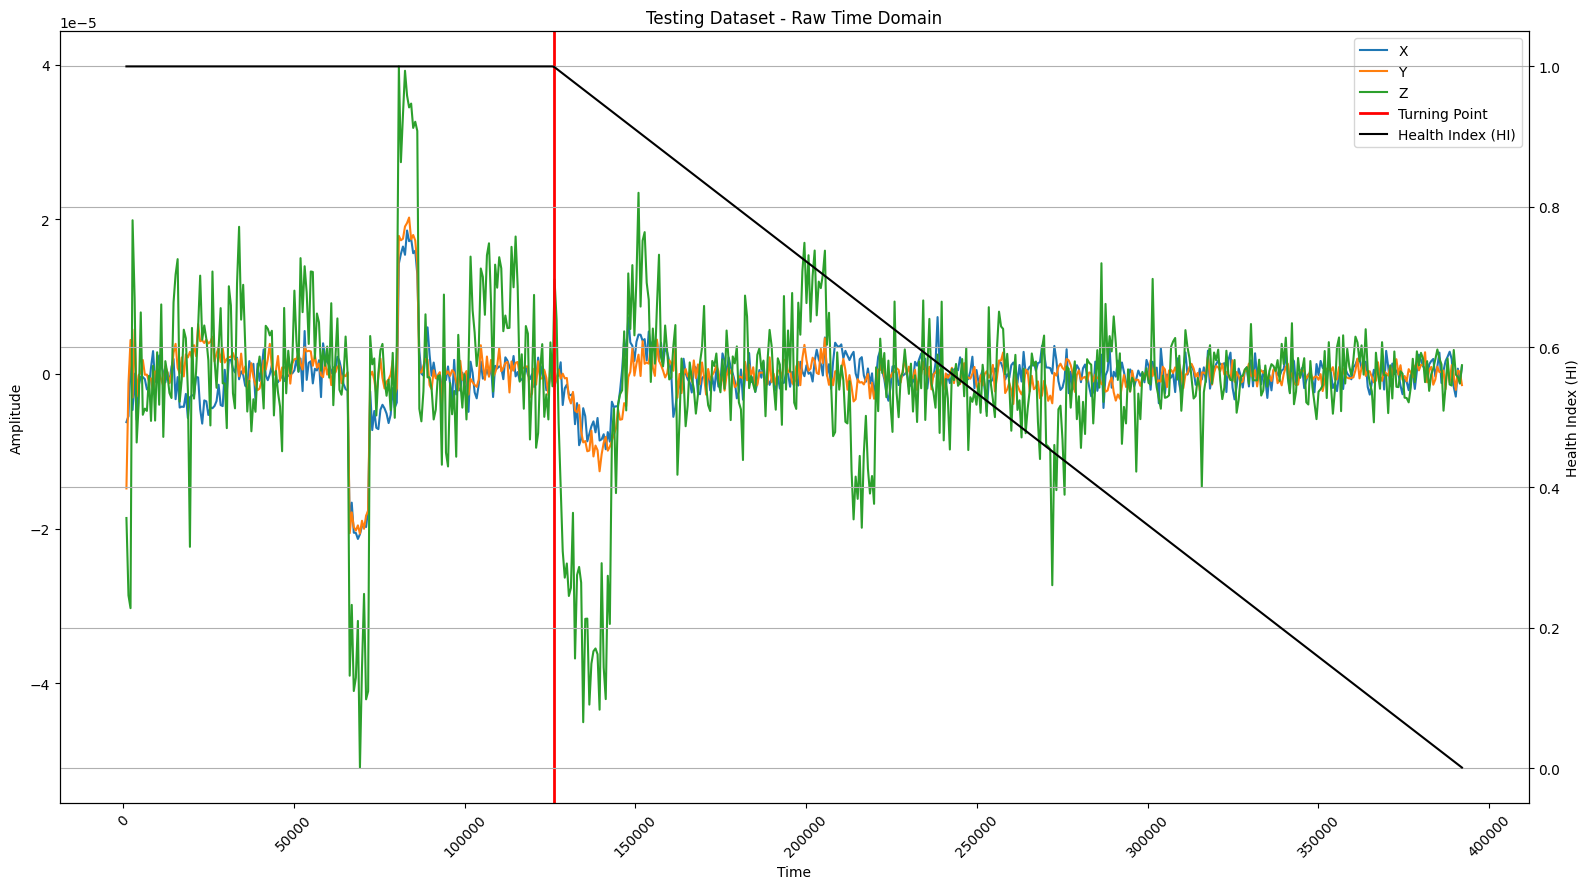

In [74]:
## Export to Parquet
if not IS_USING_FFT_DOMAIN:
    export_path = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_train_data.parquet"   
else:
    export_path = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_train_data.parquet" 

DATASET_TRAINING.to_parquet(
    export_path, 
    engine="pyarrow",
    compression="snappy"
)

if not IS_USING_FFT_DOMAIN:
    plot_dataset_with_health_index(
        series_time=DATASET_TRAINING['time'],
        vis_data_X=DATASET_TRAINING['X'],
        vis_data_Y=DATASET_TRAINING['Y'],
        vis_data_Z=DATASET_TRAINING['Z'],
        label_X='X',
        label_Y='Y',
        label_Z='Z',
        title=f"Training Dataset - Raw Time Domain",
        health_index=DATASET_TRAINING['health_index'],
        turning_point_time=TURNING_POINT_TIME,
    )
else:
    plot_dataset_with_health_index(
        series_time=DATASET_TRAINING['time'],
        vis_data_X=DATASET_TRAINING['FFT_X'],
        vis_data_Y=DATASET_TRAINING['FFT_Y'],
        vis_data_Z=DATASET_TRAINING['FFT_Z'],
        label_X='FFT_X',
        label_Y='FFT_Y',
        label_Z='FFT_Z',
        title=f"FFT - Training Dataset ({FREQUENCY_MIN} - {FREQUENCY_MAX})",
        health_index=DATASET_TRAINING['health_index'],
        turning_point_time=TURNING_POINT_TIME,
    )

## Export to Parquet
if not IS_USING_FFT_DOMAIN:
    export_path = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_test_data.parquet"
else:
    export_path = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_test_data.parquet"
    

FFT_DATASET_TESTING.to_parquet(
    export_path, 
    engine="pyarrow",
    compression="snappy"
)
if not IS_USING_FFT_DOMAIN:
    plot_dataset_with_health_index(
        series_time=FFT_DATASET_TESTING['time'],
        vis_data_X=FFT_DATASET_TESTING['X'],
        vis_data_Y=FFT_DATASET_TESTING['Y'],
        vis_data_Z=FFT_DATASET_TESTING['Z'],
        label_X='X',
        label_Y='Y',
        label_Z='Z',
        title=f"Testing Dataset - Raw Time Domain",
        health_index=FFT_DATASET_TESTING['health_index'],
        turning_point_time=TURNING_POINT_TIME,
    )
else:
    plot_dataset_with_health_index(
        series_time=FFT_DATASET_TESTING['time'],
        vis_data_X=FFT_DATASET_TESTING['FFT_X'],
        vis_data_Y=FFT_DATASET_TESTING['FFT_Y'],
        vis_data_Z=FFT_DATASET_TESTING['FFT_Z'],
        label_X='FFT_X',
        label_Y='FFT_Y',
        label_Z='FFT_Z',
        title=f"FFT - Testing Dataset ({FREQUENCY_MIN} - {FREQUENCY_MAX})",
        health_index=FFT_DATASET_TESTING['health_index'],
        turning_point_time=TURNING_POINT_TIME,
    )